# 📌 Extracción y Verificación del Archivo Tratado – Telecom X

En esta primera etapa del análisis de datos de **Telecom X**, se realiza la **carga y verificación del dataset previamente tratado** en la Parte 1 del desafío.

El objetivo principal es asegurarnos de que los datos:
- Contienen únicamente las **columnas relevantes**.
- Han sido **limpiados, estandarizados y corregidos**.
- Están listos para análisis exploratorio y modelado predictivo en las siguientes etapas.

## Actividades principales de esta sección
- ✅ **Importar el dataset** directamente desde la API en GitHub.
- ✅ **Explorar la estructura y contenido** del dataset (`head`, `info`, `shape`).
- ✅ **Verificar nombres de columnas** y renombrar si es necesario para mantener consistencia.
- ✅ Preparar la base de datos para análisis posteriores con **visualizaciones rápidas** y estadísticas descriptivas.

## Librerías utilizadas
- `pandas` → manipulación y análisis de datos.
- `seaborn` → visualizaciones estadísticas.
- `matplotlib.pyplot` → gráficos generales y personalizados.

In [136]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#urlAPI = '/content/drive/MyDrive/Challenge-DataScience-TelecomX-LATAM_Parte2/datos/datos_tratados.csv'
urlAPI = 'https://raw.githubusercontent.com/jpraden/Challenge-DataScience-TelecomX-LATAM_Parte2/main/datos/datos_tratados.csv'
df = pd.read_csv(urlAPI)
df.head()

df.info()

df = df.rename(columns={"valor_mensal": "valor_mensual"})

print(df.columns)

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   tiene +60               7032 non-null   int64  
 4   posee_pareja            7032 non-null   object 
 5   posee_dependientes      7032 non-null   object 
 6   tiempo_contrato         7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

(7032, 22)

#🛠️ **Pre procesamiento**



# 🔧 Eliminación y Ajuste de Columnas Irrelevantes

En esta etapa se realizan dos actividades principales:

1. **Eliminación de columnas que no aportan valor**  
   Algunas columnas, como **`id`** (identificador único del cliente), no ayudan a la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos. Por ello, se eliminan del dataset.

2. **Ajuste de registros en atributos categóricos**  
   Se estandarizan valores en columnas relevantes, reemplazando valores como `"Sin servicio de internet"` por `"No"` en atributos de servicios, tales como:
   - `seguridad_online`
   - `backup_online`
   - `proteccion_dispositivo`
   - `soporte_tecnico`
   - `streaming_tv`
   - `streaming_peliculas`

3. **Verificación de nulos**  
   Finalmente, se revisa que no existan valores nulos en las columnas ajustadas para asegurar consistencia en el análisis posterior.

Esta limpieza garantiza que los datos estén listos para análisis exploratorio y modelado predictivo.

In [137]:
if 'id' in df.columns:
    df = df.drop('id', axis=1)
else:
    print("Columna 'id' no encontrada, puede que haya sido eliminada.")
df.head()

df.columns

cols_to_fix = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'Sin servicio de internet': 'No'})

df.isnull().sum()

,0
Churn,0
genero,0
tiene +60,0
posee_pareja,0
posee_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_internet,0
seguridad_online,0


## Análisis Dirigido

Descripción

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

- Tiempo de contrato × Cancelación

- Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

**1. Tiempo de contrato × Cancelación**

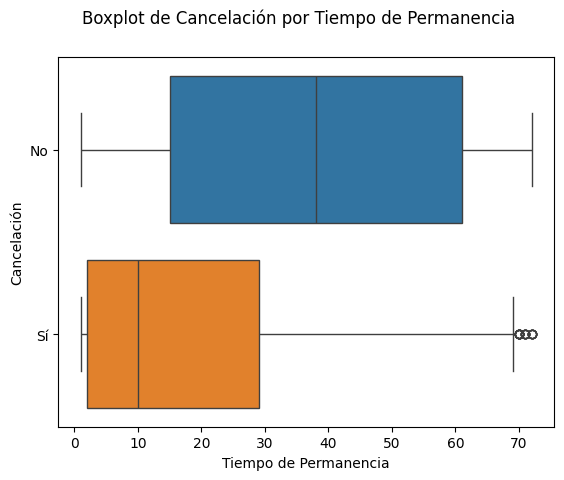

In [138]:
fig = plt.figure()
sns.boxplot(data=df, y='Churn', x='tiempo_contrato', hue='Churn')
fig.suptitle('Boxplot de Cancelación por Tiempo de Permanencia')
fig.axes[0].set_xlabel('Tiempo de Permanencia')
fig.axes[0].set_ylabel('Cancelación')
fig.axes[0].set_yticks([0, 1], labels=['No', 'Sí'])
plt.show()

# 🔍 Análisis Boxplot: Cancelación vs Tiempo de Permanencia

- **Clientes que no cancelan (No)**  
  - Mayor tiempo de permanencia en promedio.  
  - La antigüedad protege contra la cancelación.

- **Clientes que cancelan (Sí)**  
  - Tiempo de permanencia más bajo y concentrado en valores pequeños.  
  - Media: 17,9 meses, Mediana: 10 meses, Rango intercuartílico: 2–29 meses.  
  - Clientes nuevos son más vulnerables al churn.

- **Comparación general**  
  - Relación inversa clara: a mayor permanencia, menor probabilidad de cancelación.  

**Resumen:** Los clientes con más tiempo en la compañía cancelan menos; las estrategias de retención deben enfocarse en los primeros meses.

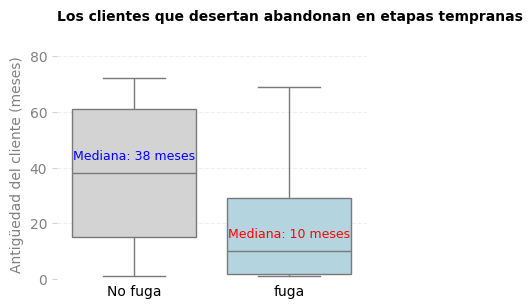

In [139]:
plt.figure(figsize=(4,3))

fuga_clientes_series = df['Churn'].map({'No': 'No fuga', 'Sí': 'fuga'})

sns.boxplot(
    data=df,
    x=fuga_clientes_series,
    y='tiempo_contrato',
    hue=fuga_clientes_series,
    palette={'No fuga': 'lightgray', 'fuga': 'lightblue'},
    showfliers=False,
    legend=False
)

plt.xticks([0,1], ['No fuga', 'fuga'])

plt.title(
    'Los clientes que desertan abandonan en etapas tempranas',
    fontsize=10,
    weight='bold',
    loc='left',
    pad=20
)


median_no_fuga = df.loc[fuga_clientes_series == 'No fuga', 'tiempo_contrato'].median()
median_fuga = df.loc[fuga_clientes_series == 'fuga', 'tiempo_contrato'].median()


plt.ylim(0, df['tiempo_contrato'].max() * 1.15)


plt.text(
    0, median_no_fuga + 5,
    f'Mediana: {int(median_no_fuga)} meses',
    ha='center',
    fontsize=9,
    color='blue'
)


plt.text(
    1, median_fuga + 5,
    f'Mediana: {int(median_fuga)} meses',
    ha='center',
    fontsize=9,
    color='red'
)

plt.ylabel('Antigüedad del cliente (meses)', color='gray')
plt.yticks(color='gray')
plt.tick_params(axis='y', color='lightgray')
plt.tick_params(axis='x', color='lightgray', size=0)
plt.xlabel('')

plt.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine(left=True, bottom=True)

plt.show()

# 🔍 Análisis: Antigüedad del Cliente vs Churn

- **Clientes que no cancelan (No Churn)**  
  - Mediana: 29 meses → la mayoría llevan más de 2 años en la compañía.  
  - Distribución amplia, refleja estabilidad y lealtad.

- **Clientes que cancelan (Churn = Sí)**  
  - Mediana: 10 meses → la mitad abandona antes de un año.  
  - Caja concentrada en valores bajos → fuga temprana.

- **Resumen**  
  - Mayor antigüedad protege contra la cancelación.  
  - Estrategias de retención deben enfocarse en los primeros 12 meses, periodo crítico de abandono.


**2.  Cancelación por Cargos Totales**

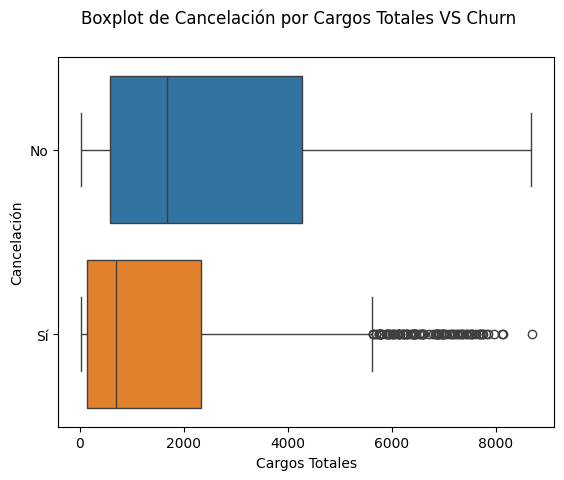

In [140]:
fig = plt.figure()
sns.boxplot(data=df, y='Churn', x='total_cobrado', hue='Churn')
fig.suptitle('Boxplot de Cancelación por Cargos Totales VS Churn')
fig.axes[0].set_xlabel('Cargos Totales')
fig.axes[0].set_ylabel('Cancelación')
fig.axes[0].set_yticks([0, 1], labels=['No', 'Sí'])
plt.show()

# 🔍 Análisis Boxplot: Cancelación vs Cargos Totales

- **Clientes que no cancelan (No)**  
  - Distribución más amplia y valores promedio más altos.  
  - Refleja mayor permanencia y estabilidad.

- **Clientes que cancelan (Sí)**  
  - Cargos totales más bajos.  
  - La mayoría abandona antes de acumular grandes pagos.

- **Resumen**  
  - Relación inversa: menor gasto acumulado → mayor riesgo de churn.  
  - Estrategias de retención deben enfocarse en clientes de bajo gasto acumulado.


## 📊 EDA
**1. Correlación entre variables numericas**

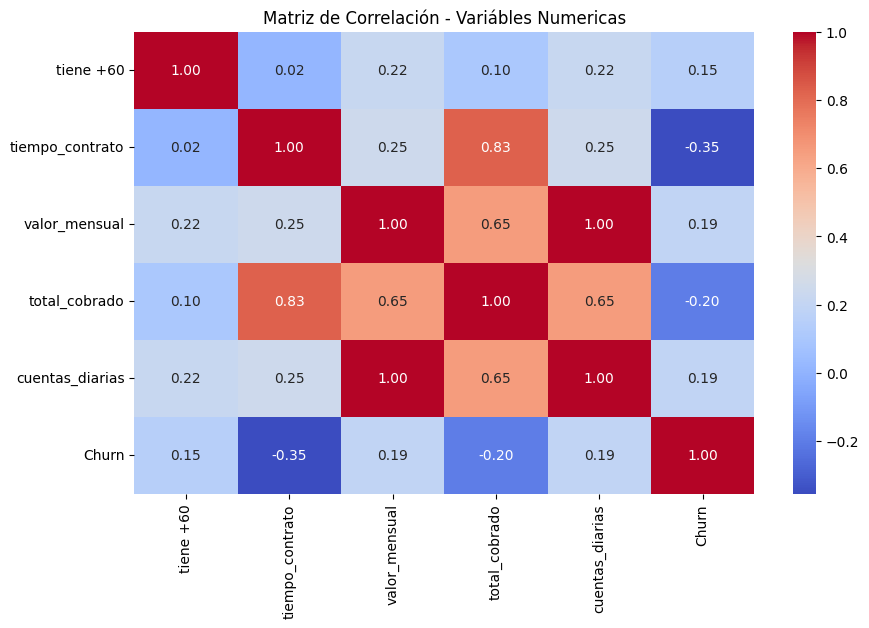

In [141]:
  #Copia "df" respaldo
df_respaldo = df.copy()

  # Correlación entre variables numericas
  df_corrVariablesNumericas = df.select_dtypes(include=["int64", "float64"])

  df_corrVariablesNumericas["Churn"] = df["Churn"].map({"Sí": 1, "No": 0})

  corr_matrix = df_corrVariablesNumericas.corr()

  # Visualizar heatmap
  plt.figure(figsize=(10,6))
  sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
  plt.title("Matriz de Correlación - Variábles Numericas")
  plt.show()



In [142]:
df_corrVariablesNumericas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tiene +60        7032 non-null   int64  
 1   tiempo_contrato  7032 non-null   int64  
 2   valor_mensual    7032 non-null   float64
 3   total_cobrado    7032 non-null   float64
 4   cuentas_diarias  7032 non-null   float64
 5   Churn            7032 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 329.8 KB


In [143]:
df_corrVariablesNumericas = df_corrVariablesNumericas.drop(columns=["cuentas_diarias","total_cobrado"])
print("********************************************************!")
print("Columna 'cuentas_diarias' y 'total_cobrado', Eliminadas!!")
print("********************************************************!")
df_corrVariablesNumericas.info()

********************************************************!
Columna 'cuentas_diarias' y 'total_cobrado', Eliminadas!!
********************************************************!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tiene +60        7032 non-null   int64  
 1   tiempo_contrato  7032 non-null   int64  
 2   valor_mensual    7032 non-null   float64
 3   Churn            7032 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 219.9 KB


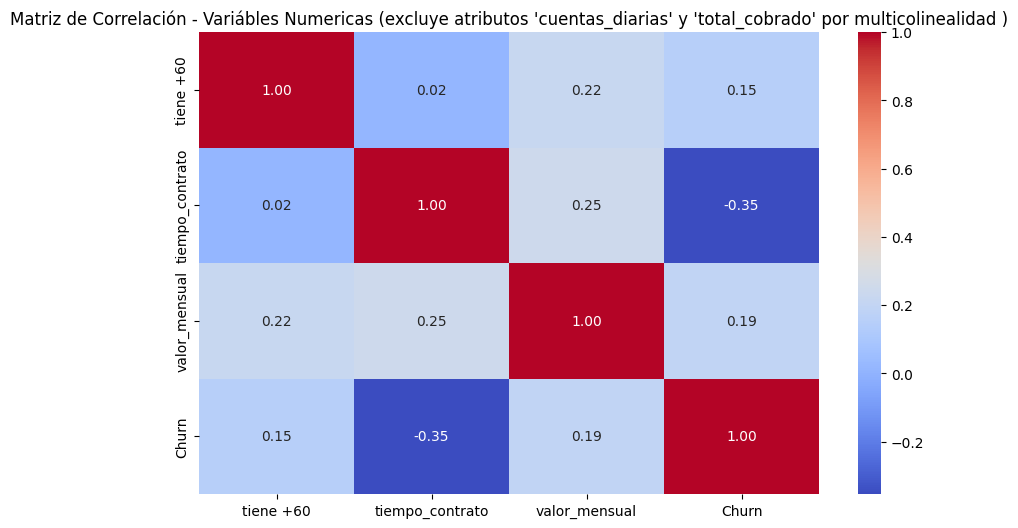

In [144]:

corr_matrix = df_corrVariablesNumericas.corr()


plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas (excluye atributos 'cuentas_diarias' y 'total_cobrado' por multicolinealidad )")
plt.show()


In [145]:

df = df.drop(columns=["cuentas_diarias","total_cobrado"])

# Resultados Matriz de Correlación (Variables Numéricas)

- **tiempo_contrato**: correlación negativa moderada con Churn (-0.35) → contratos más largos reducen la probabilidad de cancelación. Predictor numérico más relevante.  
- **valor_mensual**: correlación positiva débil (0.19) → cargos mensuales altos se asocian ligeramente con mayor churn.  
- **tiene +60**: correlación positiva débil (0.15) → clientes mayores muestran leve tendencia a cancelar.  

**Resumen:** La duración del contrato es el factor numérico más significativo; las demás variables aportan información secundaria.



**2. Analisis de churn por categoria (variables categoricas)**

 - Seleccionar variables categoricas
 - Tabla de proporción por categoria

In [146]:
variables_categoricas = df.select_dtypes(include=["object"]).columns
variables_categoricas = variables_categoricas.drop("Churn")

for col in variables_categoricas:
    print(f"\n🔍 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


🔍 Analisis de variable: genero


Churn,No,Sí
genero,,
Femenino,73.040482,26.959518
Masculino,73.795435,26.204565



🔍 Analisis de variable: posee_pareja


Churn,No,Sí
posee_pareja,,
No,67.023908,32.976092
Sí,80.282935,19.717065



🔍 Analisis de variable: posee_dependientes


...

Churn,No,Sí
tipo_contrato,,
Anual,88.722826,11.277174
Bianual,97.151335,2.848665
Mensual,57.290323,42.709677



🔍 Analisis de variable: factura_digital


Churn,No,Sí
factura_digital,,
No,83.624302,16.375698
Yes,66.410749,33.589251



🔍 Analisis de variable: metodo_pago


Churn,No,Sí
metodo_pago,,
Cheque electrónico,54.714588,45.285412
Cheque enviado por correo,80.798005,19.201995
Tarjeta de crédito (automático),84.746877,15.253123
Transferencia bancaria (automática),83.268482,16.731518


# 🎯 Método Recomendado: Chi-Cuadrado (Chi-Square Test)

- Evalúa la **independencia o asociación** entre variables categóricas y la variable objetivo (**Churn**).  
- **Interpretación del p-value**:  
  - **p < 0.05** → variable significativamente asociada con Churn.  
  - **p > 0.05** → variable no relevante; podría eliminarse.  
- Útil para identificar patrones y relaciones importantes para decisiones o modelado predictivo.



In [147]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

df_rank = df.copy()

df_rank["Churn"] = df_rank["Churn"].map({"Sí": 1, "No": 0})

variables_categoricas = df_rank.select_dtypes(include=["object"]).columns

le = LabelEncoder()
for col in variables_categoricas:
    df_rank[col] = le.fit_transform(df_rank[col])

X_cat = df_rank[variables_categoricas]
y = df_rank["Churn"]

chi_scores, p_values = chi2(X_cat, y)

chi_df = pd.DataFrame({
    "Variable": variables_categoricas,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

print("//****************************************************//")
print("Ranking de variables categóricas respecto a Churn:")
print("//****************************************************//")

print(chi_df)
print("//****************************************************//")

variables_a_eliminar = chi_df[chi_df["p-value"] > 0.05]["Variable"].tolist()
print("\n\n//------------------------------------------------------------------//")
print("\033[1mVariables menos significativas (candidatas a eliminar):\033[1m")
print("\033[1m***", variables_a_eliminar, "***\033[0m")
print("//------------------------------------------------------------------//")

//****************************************************//
Ranking de variables categóricas respecto a Churn:
//****************************************************//
                  Variable  Chi2 Score        p-value
14             metodo_pago  466.119470  2.239792e-103
12           tipo_contrato  392.706273   2.131687e-87
6         seguridad_online  147.165601   7.219883e-34
9          soporte_tecnico  135.439602   2.645952e-31
2       posee_dependientes  131.271509   2.159540e-30
13         factura_digital  104.979224   1.234232e-24
1             posee_pareja   81.857769   1.462409e-19
7            backup_online   31.209832   2.315902e-08
8   proteccion_dispositivo   20.216007   6.917171e-06
10            streaming_tv   17.320615   3.157429e-05
11     streaming_peliculas   15.930611   6.570739e-05
4         multiples_lineas    9.735960   1.806976e-03
5            tipo_internet    9.715269   1.827433e-03
0                   genero    0.254297   6.140655e-01
3        servicio_telefon

In [148]:
variables_significativas = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(variables_significativas)



✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
14,metodo_pago,466.119470,2.239792e-103
12,tipo_contrato,392.706273,2.131687e-87
6,seguridad_online,147.165601,7.219883e-34
9,soporte_tecnico,135.439602,2.645952e-31
2,posee_dependientes,131.271509,2.159540e-30
13,factura_digital,104.979224,1.234232e-24
1,posee_pareja,81.857769,1.462409e-19
7,backup_online,31.209832,2.315902e-08
8,proteccion_dispositivo,20.216007,6.917171e-06
10,streaming_tv,17.320615,3.157429e-05


In [149]:
variables_significativas = chi_df[chi_df["p-value"] > 0.05]

print("\n✅ Variables a Eliminar por evita multicolinealidad:")
display(variables_significativas)


✅ Variables a Eliminar por evita multicolinealidad:


,Variable,Chi2 Score,p-value
0,genero,0.254297,0.614066
3,servicio_telefono,0.092948,0.760462


# 📊 Resultados Chi-Cuadrado (Variables Categóricas)

- **Variables altamente significativas (p muy bajo)** → fuerte asociación con Churn:  
  `metodo_pago`, `tipo_contrato`, `seguridad_online`, `soporte_tecnico`, `posee_dependientes`, `factura_digital`, `posee_pareja`.

- **Variables con relevancia moderada** → aportan información, pero menor fuerza:  
  `backup_online`, `proteccion_dispositivo`, `streaming_tv`, `streaming_peliculas`, `multiples_lineas`, `tipo_internet`.

- **Variables con baja significancia** → candidatas a eliminar:  
  `genero`, `servicio_telefono`.

**Resumen:**  
Mantener las variables más significativas para reducir ruido y enfocarse en las que aportan mayor poder explicativo sobre la cancelación de clientes. Variables de relevancia moderada pueden considerarse opcionales; las de baja significancia pueden eliminarse.

In [150]:
df = df.drop(columns=["genero", "servicio_telefono"])
#df = df.drop(columns=["genero", "servicio_telefono","multiples_lineas","tipo_internet"])


## 🎯 Split -1 - Separando el Dataset ("X" e "y")

- X (variables predictoras): contiene todas las demás características que explican o influyen en la cancelación.
- y (variable objetivo): contiene la información que queremos predecir (en este caso, si el cliente cancela o no).

_____________________________________________________________________________



In [151]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Sí": 1, "No": 0})

# 🔹 Separación de "X" y "y"

Separar **X** (variables explicativas) y **y** (variable objetivo) es fundamental por varias razones:

- **Evita transformar la variable objetivo:**  
  El preprocesamiento (escalado, codificación, imputación) debe aplicarse solo a las variables explicativas. Incluir `Churn` en este proceso distorsionaría la variable que queremos predecir.

- **Claridad en el flujo de trabajo:**  
  `X` se usa para entrenar el modelo y `y` como etiqueta supervisora, permitiendo aplicar transformaciones solo a `X`.

- **Compatibilidad con librerías de ML:**  
  Funciones como `train_test_split`, `fit` y `predict` de scikit-learn requieren que `X` y `y` estén separados (`X` como matriz de características, `y` como vector objetivo).

**Resumen:**  
Separar `X` y `y` asegura que la variable objetivo no se distorsione, el preprocesamiento afecte solo a las variables explicativas y el modelo pueda entrenarse y evaluarse correctamente.


## 🎯 Split -2

- X se usa para entrenar el modelo.
- y se usa como etiqueta para supervisar el aprendizaje.
- Esto permite aplicar transformaciones solo a X (ej. escalado, encoding, imputación de valores).
- Compatibilidad con librerías de machine learning:
- Funciones como train_test_split, fit, predict en scikit-learn esperan que X y y estén separados.
- X debe ser una matriz de características, y y un vector con la variable objetivo.

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [153]:
X_train.head(3)

,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
1416,0,Sí,No,37,No,Sin servicio de internet,No,No,No,No,No,No,Mensual,No,Transferencia bancaria (automática),20.35
6993,0,Sí,Sí,68,No,Fibra optica,Sí,No,No,Sí,Sí,Sí,Bianual,Yes,Cheque electrónico,99.55
3417,1,No,No,3,No,Fibra optica,No,No,Sí,No,No,No,Mensual,No,Cheque electrónico,73.85


In [154]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1416 to 1465
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tiene +60               5625 non-null   int64  
 1   posee_pareja            5625 non-null   object 
 2   posee_dependientes      5625 non-null   object 
 3   tiempo_contrato         5625 non-null   int64  
 4   multiples_lineas        5625 non-null   object 
 5   tipo_internet           5625 non-null   object 
 6   seguridad_online        5625 non-null   object 
 7   backup_online           5625 non-null   object 
 8   proteccion_dispositivo  5625 non-null   object 
 9   soporte_tecnico         5625 non-null   object 
 10  streaming_tv            5625 non-null   object 
 11  streaming_peliculas     5625 non-null   object 
 12  tipo_contrato           5625 non-null   object 
 13  factura_digital         5625 non-null   object 
 14  metodo_pago             5625 non-null   ob

In [155]:
X_train.shape

(5625, 16)

In [156]:
X_test.head(3)

,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
984,0,No,No,12,No,Sin servicio de internet,No,No,No,No,No,No,Anual,No,Cheque enviado por correo,19.7
654,0,No,No,7,No,Fibra optica,No,No,No,No,No,No,Mensual,Yes,Cheque enviado por correo,69.9
4341,0,No,No,62,Sí,Sin servicio de internet,No,No,No,No,No,No,Bianual,No,Transferencia bancaria (automática),23.4


In [157]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 984 to 2092
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tiene +60               1407 non-null   int64  
 1   posee_pareja            1407 non-null   object 
 2   posee_dependientes      1407 non-null   object 
 3   tiempo_contrato         1407 non-null   int64  
 4   multiples_lineas        1407 non-null   object 
 5   tipo_internet           1407 non-null   object 
 6   seguridad_online        1407 non-null   object 
 7   backup_online           1407 non-null   object 
 8   proteccion_dispositivo  1407 non-null   object 
 9   soporte_tecnico         1407 non-null   object 
 10  streaming_tv            1407 non-null   object 
 11  streaming_peliculas     1407 non-null   object 
 12  tipo_contrato           1407 non-null   object 
 13  factura_digital         1407 non-null   object 
 14  metodo_pago             1407 non-null   obj

In [158]:
X_test.shape

(1407, 16)

In [159]:
y_train.head(3)

,Churn
1416,0
6993,0
3417,0


In [160]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 5625 entries, 1416 to 1465
Series name: Churn
Non-Null Count  Dtype
--------------  -----
5625 non-null   int64
dtypes: int64(1)
memory usage: 87.9 KB


In [161]:
y_train.shape

(5625,)

In [162]:
y_test.shape

(1407,)

# 🔍 Resultados Split de Datos: X_train, X_test, y_train, y_test

- **Datos de Entrenamiento**  
  - `X_train`: 5.625 filas × 16 columnas (variables predictoras)  
  - `y_train`: 5.625 filas × 1 columna (`Churn`: variable objetivo)  

- **Datos para Evaluación del Modelo**  
  - `X_test`: 1.407 filas × 16 columnas  
  - `y_test`: 1.407 filas × 1 columna (`Churn`)  

> Nota: Ninguna variable ha sido transformada todavía; el preprocesamiento (One-Hot Encoding) se aplicará en el siguiente paso.

---

### 🔹 Cómo funciona la separación
- `test_size=0.2` → 20% de los datos se reserva para prueba, 80% para entrenamiento.  
- `stratify=y` → mantiene la proporción de clases en ambos conjuntos, crucial en problemas de Churn desbalanceados.  
- `random_state=42` → asegura que la división sea reproducible.  

**Resumen:**  
`train_test_split` divide los datos en entrenamiento (`X_train`, `y_train`) y evaluación (`X_test`, `y_test`) para que el modelo aprenda con unos ejemplos y se pruebe con otros que nunca ha visto.


##  3. One-Hot Encoding

In [163]:
X_train = pd.get_dummies(X_train, drop_first=True)

X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [164]:
X_train.head(3)

,tiene +60,tiempo_contrato,valor_mensual,posee_pareja_Sí,posee_dependientes_Sí,multiples_lineas_Sin servicio de teléfono,multiples_lineas_Sí,tipo_internet_Fibra optica,tipo_internet_Sin servicio de internet,seguridad_online_Sí,...,proteccion_dispositivo_Sí,soporte_tecnico_Sí,streaming_tv_Sí,streaming_peliculas_Sí,tipo_contrato_Bianual,tipo_contrato_Mensual,factura_digital_Yes,metodo_pago_Cheque enviado por correo,metodo_pago_Tarjeta de crédito (automático),metodo_pago_Transferencia bancaria (automática)
1416,0,37,20.35,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
6993,0,68,99.55,True,True,False,False,True,False,True,...,False,True,True,True,True,False,True,False,False,False
3417,1,3,73.85,False,False,False,False,True,False,False,...,True,False,False,False,False,True,False,False,False,False


In [165]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1416 to 1465
Data columns (total 21 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   tiene +60                                        5625 non-null   int64  
 1   tiempo_contrato                                  5625 non-null   int64  
 2   valor_mensual                                    5625 non-null   float64
 3   posee_pareja_Sí                                  5625 non-null   bool   
 4   posee_dependientes_Sí                            5625 non-null   bool   
 5   multiples_lineas_Sin servicio de teléfono        5625 non-null   bool   
 6   multiples_lineas_Sí                              5625 non-null   bool   
 7   tipo_internet_Fibra optica                       5625 non-null   bool   
 8   tipo_internet_Sin servicio de internet           5625 non-null   bool   
 9   seguridad_online_Sí             

In [166]:
X_train.shape

(5625, 21)

In [167]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 984 to 2092
Data columns (total 21 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   tiene +60                                        1407 non-null   int64  
 1   tiempo_contrato                                  1407 non-null   int64  
 2   valor_mensual                                    1407 non-null   float64
 3   posee_pareja_Sí                                  1407 non-null   bool   
 4   posee_dependientes_Sí                            1407 non-null   bool   
 5   multiples_lineas_Sin servicio de teléfono        1407 non-null   bool   
 6   multiples_lineas_Sí                              1407 non-null   bool   
 7   tipo_internet_Fibra optica                       1407 non-null   bool   
 8   tipo_internet_Sin servicio de internet           1407 non-null   bool   
 9   seguridad_online_Sí              

In [168]:
X_test.head(3)

,tiene +60,tiempo_contrato,valor_mensual,posee_pareja_Sí,posee_dependientes_Sí,multiples_lineas_Sin servicio de teléfono,multiples_lineas_Sí,tipo_internet_Fibra optica,tipo_internet_Sin servicio de internet,seguridad_online_Sí,...,proteccion_dispositivo_Sí,soporte_tecnico_Sí,streaming_tv_Sí,streaming_peliculas_Sí,tipo_contrato_Bianual,tipo_contrato_Mensual,factura_digital_Yes,metodo_pago_Cheque enviado por correo,metodo_pago_Tarjeta de crédito (automático),metodo_pago_Transferencia bancaria (automática)
984,0,12,19.7,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
654,0,7,69.9,False,False,False,False,True,False,False,...,False,False,False,False,False,True,True,True,False,False
4341,0,62,23.4,False,False,False,True,False,True,False,...,False,False,False,False,True,False,False,False,False,True


In [169]:
X_test.shape

(1407, 21)

In [170]:
y_train.head(3)

,Churn
1416,0
6993,0
3417,0


In [171]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 5625 entries, 1416 to 1465
Series name: Churn
Non-Null Count  Dtype
--------------  -----
5625 non-null   int64
dtypes: int64(1)
memory usage: 87.9 KB


In [172]:
y_train.shape

(5625,)

In [173]:
y_test.head(3)

,Churn
984,0
654,0
4341,0


In [174]:
y_test.info(3)

<class 'pandas.core.series.Series'>
Index: 1407 entries, 984 to 2092
Series name: Churn
Non-Null Count  Dtype
--------------  -----
1407 non-null   int64
dtypes: int64(1)
memory usage: 22.0 KB


In [175]:
y_test.shape

(1407,)

 # 🔑 Resultados One-Hot Encoding (X_train, X_test, y_train, y_test)

- **Datos de Entrenamiento**  
  - `X_train`: 5.625 filas × 21 columnas (variables predictoras transformadas)  
  - `y_train`: 5.625 filas × 1 columna (`Churn`)  

- **Datos de Evaluación**  
  - `X_test`: 1.407 filas × 21 columnas  
  - `y_test`: 1.407 filas × 1 columna (`Churn`)  

> Nota: Todas las variables están transformadas y listas para ejecución de los modelos.

---

### 🔹 Cómo funciona
1. `pd.get_dummies(X_train, drop_first=True)`  
   - Convierte variables categóricas en binarias (dummy variables).  
   - `drop_first=True` evita multicolinealidad.  

2. `pd.get_dummies(X_test, drop_first=True)`  
   - Hace lo mismo en el conjunto de prueba.  

3. `X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)`  
   - Alinea columnas entre entrenamiento y prueba, rellenando con 0 si alguna categoría falta en `X_test`.  

**Resumen:**  
- Codifica variables categóricas en formato numérico.  
- Evita multicolinealidad.  
- Garantiza consistencia entre `X_train` y `X_test` para predicciones correctas.

## 🎯4. Verificar desbalanceamiento

In [176]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
0,73.422222
1,26.577778


## 🎯5. Entrenamiento

🔹 Modelo 1 — Regresion logistica
🔹 Modelo 2 — Random Forest


 **1. Modelo 1 — Regresion logistica**

 Aquí entrenamos y evalúamos un modelo de Regresión Logística para predecir la cancelación (Churn).


In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



# 📈 Resultados Modelo: Regresión Logística

- **Clase “No” (no cancelan)**  
  - Precisión: 0.84 → 84% de predicciones correctas  
  - Recall: 0.90 → detecta correctamente al 90% de clientes que no cancelan  
  - F1-score: 0.87 → excelente equilibrio

- **Clase “Sí” (cancelan)**  
  - Precisión: 0.65 → 65% de predicciones correctas  
  - Recall: 0.52 → detecta solo al 52% de clientes que cancelan  
  - F1-score: 0.58 → rendimiento moderado

- **Global**  
  - Accuracy: 0.80 → acierto en 80% de los casos  
  - Macro avg: 0.72 → modelo menos equilibrado  
  - Weighted avg: 0.79 → refleja dominancia de la clase “No”

**Resumen:**  
El modelo identifica bien a los clientes que permanecen, pero tiene dificultades para detectar clientes que cancelan, limitando su utilidad en estrategias de retención.



**2.  Modelo 2 — Random Forest**

In [178]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# 🌲 Resultados Modelo: Random Forest

- **Clase “No” (no cancelan)**  
  - Precisión: 0.83 → 83% de predicciones correctas  
  - Recall: 0.90 → detecta correctamente al 90% de clientes que no cancelan  
  - F1-score: 0.87 → excelente equilibrio

- **Clase “Sí” (cancelan)**  
  - Precisión: 0.64 → 64% de predicciones correctas  
  - Recall: 0.50 → detecta solo la mitad de clientes que cancelan  
  - F1-score: 0.56 → rendimiento moderado

- **Global**  
  - Accuracy: 0.79 → acierto en 79% de los casos  
  - Macro avg: 0.71 → menos equilibrado  
  - Weighted avg: 0.78 → refleja dominancia de la clase “No”

**Resumen:**  
El modelo acierta en términos generales, pero tiene dificultades para identificar clientes que cancelan (recall bajo), perdiendo muchos casos de churn.

**3.  Modelo 3 — Regresión logística balanceada**

In [179]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Regresión logística balanceada")
print(classification_report(y_test, y_pred_log))

Regresión logística balanceada
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



# ⚖️ Resultados Modelo: Regresión Logística Balanceada

- **Clase “No” (no cancelan)**  
  - Precisión: 0.91 → predice con gran fiabilidad a quienes permanecen  
  - Recall: 0.73 → detecta correctamente al 73% de clientes que no cancelan  
  - F1-score: 0.81 → buen equilibrio, algo de sacrificio en recall para mantener precisión  

- **Clase “Sí” (cancelan)**  
  - Precisión: 0.52 → solo la mitad de predicciones correctas  
  - Recall: 0.80 → identifica 8 de cada 10 clientes que cancelan  
  - F1-score: 0.63 → rendimiento aceptable, mejor recall que precisión  

- **Global**  
  - Accuracy: 0.75 → acierto en 75% de los casos  
  - Macro avg: 0.72 → balance razonable entre clases  
  - Weighted avg: 0.76 → refleja dominancia de la clase “No”  

**Resumen:**  
Modelo útil para detectar clientes en riesgo de cancelar, priorizando retención. Mejora recall de la clase “Sí” a costa de precisión y accuracy global, un trade-off típico en problemas de churn.

**4.  Modelo 4 — Regresión Logística con balanceo y SMOTE**

In [180]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Sí": 1, "No": 0})

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train_res_scaled, y_train_res)


y_pred = log_model.predict(X_test_scaled)

print("Regresión Logística con balanceo y SMOTE")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:\n", cm)

Regresión Logística con balanceo y SMOTE
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.54      0.69      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407

Matriz de Confusión:
 [[813 220]
 [115 259]]


# ⚖️ Regresión Logística con Balanceo y SMOTE

- **Clase 0 (No Churn)**  
  - Precisión: 0.88 → predice correctamente la mayoría que no abandona  
  - Recall: 0.79 → 21% de falsos positivos  
  - Buen desempeño en la clase mayoritaria, con algunos errores  

- **Clase 1 (Sí Churn)**  
  - Precisión: 0.54 → solo un poco más de la mitad de predicciones correctas  
  - Recall: 0.69 → identifica casi 7 de cada 10 clientes que abandonan  
  - Mejora detección de la clase minoritaria gracias a SMOTE, aunque hay falsos positivos  

- **Métricas globales**  
  - Accuracy: 0.76 → acierta en 3 de cada 4 casos  
  - Macro promedio: 0.71–0.74 → equilibrio aceptable  
  - Weighted promedio: 0.76–0.79 → buen desempeño general  

**Resumen:**  
El balanceo con SMOTE mejora la detección de clientes que abandonan (recall de la clase “Sí”), sacrificando precisión. Ideal cuando la prioridad es capturar casos de churn, incluso con algunos falsos positivos.

## 🎯6. Evaluación

Matriz de Confusión:
 [[754 279]
 [ 76 298]]


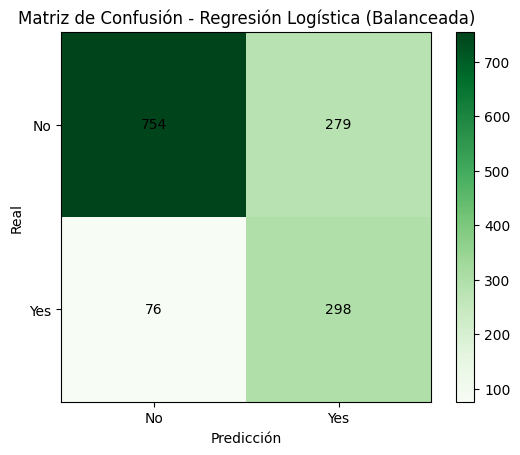

In [181]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm, interpolation="nearest", cmap="Greens")  # Cambiado a verde
plt.title("Matriz de Confusión - Regresión Logística (Balanceada)")
plt.xlabel("Predicción")
plt.ylabel("Real")

# Matriz de confusión en consola
print("Matriz de Confusión:\n", cm)

# Anotar valores dentro de la matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

# Etiquetas de ejes
plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])

# Barra de color para referencia
plt.colorbar()

plt.show()

# 🔍 Matriz de Confusión – Regresión Logística (Balanceada)

- **Clase “No” (clientes que no cancelan)**  
  - Verdaderos negativos: 754 → predijo “No” y efectivamente no cancelaron  
  - Falsos positivos: 279 → predijo “Sí” pero en realidad no cancelaron  

- **Clase “Sí” (clientes que cancelan)**  
  - Falsos negativos: 76 → predijo “No” pero en realidad sí cancelaron  
  - Verdaderos positivos: 298 → predijo “Sí” y efectivamente cancelaron  

**Resumen:**  
El modelo identifica bien a clientes que permanecen y aceptablemente a los que cancelan. El balanceo permitió que la clase minoritaria sea detectada, aumentando la intervención sobre clientes en riesgo, aunque también se generan más falsos positivos. Esto significa que algunas alertas serán preventivas, incluso si algunos clientes finalmente no se van.

***Matriz de Confusión - Regresión Logística normal ***


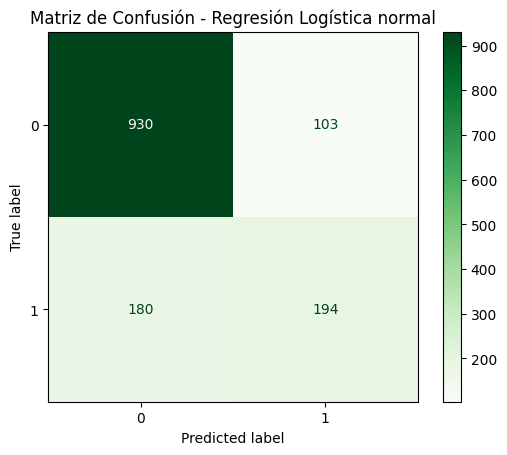

In [182]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log_normal)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model.classes_)
disp.plot(cmap=plt.cm.Greens)

plt.title("Matriz de Confusión - Regresión Logística normal")
plt.show()

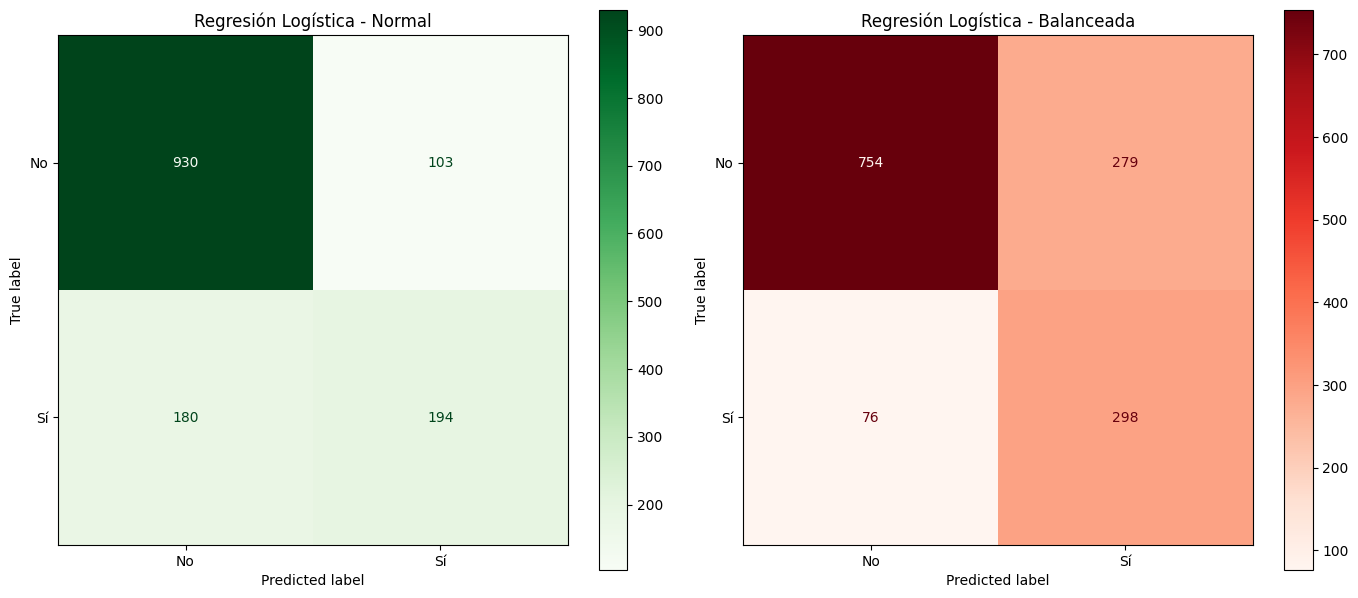

In [183]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_normal = confusion_matrix(y_test, y_pred_log_normal)
disp_normal = ConfusionMatrixDisplay(confusion_matrix=cm_normal, display_labels=["No", "Sí"])

cm_balanced = confusion_matrix(y_test, y_pred_log)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=["No", "Sí"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_normal.plot(cmap="Greens", ax=axes[0], values_format='d')
axes[0].set_title("Regresión Logística - Normal", fontsize=12)

disp_balanced.plot(cmap="Reds", ax=axes[1], values_format='d')
axes[1].set_title("Regresión Logística - Balanceada", fontsize=12)

plt.tight_layout()
plt.show()

 # 🔄 Comparación Matriz de Confusión – Regresión Logística (Normal vs Balanceado)

1. **Modelo Normal (paleta verde)**  
   - La diagonal principal muestra los aciertos, predominando la clase mayoritaria (“No”).  
   - Errores frecuentes en la clase minoritaria (“Sí”), con más falsos negativos.  
   - Tiende a favorecer la clase mayoritaria, mostrando sesgo.

2. **Modelo Balanceado (paleta roja)**  
   - Mejora la detección de la clase minoritaria (“Sí”), aunque puede sacrificar precisión en la clase mayoritaria.  
   - Reduce falsos negativos y aumenta el recall de la clase crítica.  
   - Distribución más equitativa de aciertos entre ambas clases, útil cuando “Sí” representa un evento importante.

**Resumen:**  
- Para minimizar riesgo de pasar por alto clientes que cancelan (“Sí”), **usar modelo balanceado**.  
- Para priorizar precisión global sin importar sesgo, **el modelo normal puede ser suficiente**.



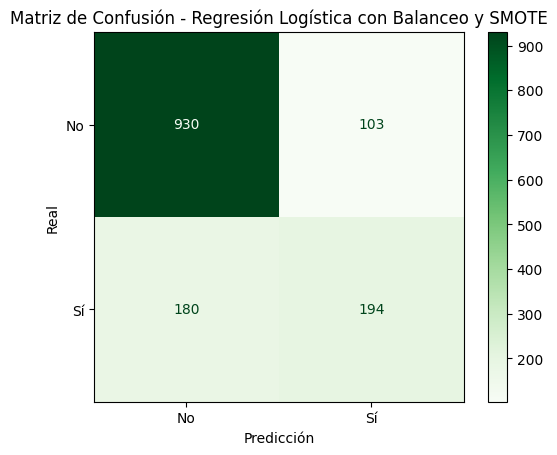

In [184]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(cmap="Greens", values_format='d')

plt.title("Matriz de Confusión - Regresión Logística con Balanceo y SMOTE")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

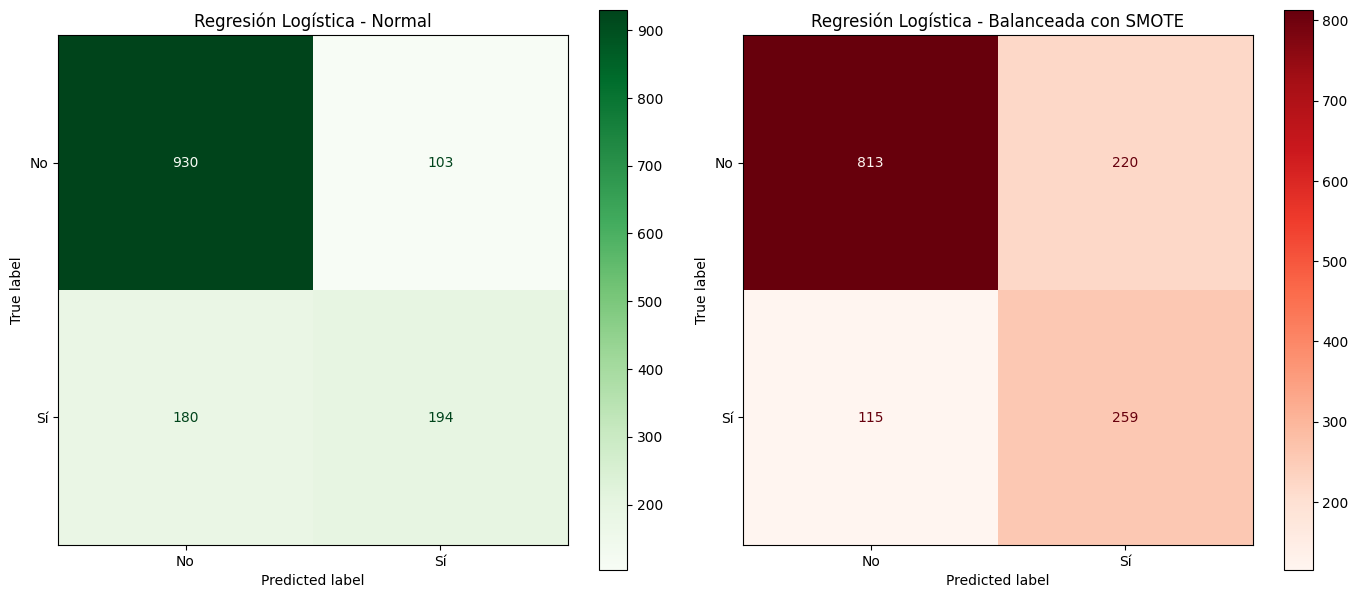

In [185]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_normal = confusion_matrix(y_test, y_pred_log_normal)
disp_normal = ConfusionMatrixDisplay(confusion_matrix=cm_normal, display_labels=["No", "Sí"])

cm_balanced = confusion_matrix(y_test, y_pred)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=["No", "Sí"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_normal.plot(cmap="Greens", ax=axes[0], values_format='d')
axes[0].set_title("Regresión Logística - Normal", fontsize=12)

disp_balanced.plot(cmap="Reds", ax=axes[1], values_format='d')
axes[1].set_title("Regresión Logística - Balanceada con SMOTE", fontsize=12)

plt.tight_layout()


plt.show()

# 🔄 Comparación Matriz de Confusión – Regresión Logística (Normal vs Balanceado con SMOTE)

- **Modelo Normal (sin balanceo)**  
  - Favorece la clase mayoritaria (“No”), con alta precisión en clientes que no abandonan.  
  - Recall bajo en la clase minoritaria (“Sí”), muchos casos de churn no se detectan.  
  - Riesgo: subestimación del churn, crítico para decisiones de retención.

- **Modelo Balanceado con SMOTE**  
  - Mejora el recall de la clase “Sí” (0.69), identificando más clientes que realmente abandonan.  
  - Menor precisión (0.54), generando más falsos positivos.  
  - Ventaja: útil si la prioridad es no perder casos de churn, incluso con alertas falsas.

**Resumen:**  
- Modelo normal → mayor precisión en la clase “No”.  
- Modelo balanceado con SMOTE → mejor equilibrio y detección de churn.  
- Elección según estrategia: minimizar falsos positivos o maximizar detección de clientes en riesgo.


## 🎯7. Coeficientes de Regresión Lógistica

indica la influencia de cada variable en la probabilidad de churn (abandono), manteniendo las demás constantes. En este tipo de modelo:
- Coeficientes positivos → aumentan la probabilidad de churn.
- Coeficientes negativos → disminuyen la probabilidad de churn.
- La magnitud del coeficiente refleja la fuerza de la relación (aunque no es directamente interpretable como probabilidad, sí como dirección e intensidad relativa).


In [186]:
import pandas as pd

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coeficiente", ascending=False)
display(coef_df)

,Variable,Coeficiente
7,tipo_internet_Fibra optica,3.652003
13,streaming_tv_Sí,1.396145
14,streaming_peliculas_Sí,1.386687
6,multiples_lineas_Sí,0.863093
11,proteccion_dispositivo_Sí,0.657909
16,tipo_contrato_Mensual,0.616364
10,backup_online_Sí,0.587998
9,seguridad_online_Sí,0.443702
17,factura_digital_Yes,0.394014
12,soporte_tecnico_Sí,0.371856


# 🔍 Análisis Coeficientes – Regresión Logística

- **Mayor riesgo de churn (coeficientes positivos altos)**  
  - `tipo_internet_Fibra óptica` (3.65) → Fibra óptica aumenta probabilidad de abandono  
  - `streaming_tv_Sí` (1.39) y `streaming_peliculas_Sí` (1.38) → Uso de streaming se asocia con mayor churn  
  - `multiples_lineas_Sí` (0.86) → Tener múltiples líneas incrementa el riesgo  
  - `tipo_contrato_Mensual` (0.61) → Contratos mensuales aumentan la probabilidad de abandono  

- **Factores protectores (coeficientes negativos)**  
  - `valor_mensual` (-7.20) → Clientes de alto valor son más estables  
  - `tipo_internet_Sin servicio de internet` (-2.46) → No tener internet reduce churn  
  - `multiples_lineas_Sin servicio de teléfono` (-1.27) → No tener teléfono reduce riesgo  
  - `tiempo_contrato` (-0.94) → Mayor antigüedad disminuye probabilidad de abandono  

- **Efecto moderado o nulo**  
  - `metodo_pago_Tarjeta de crédito` (0.05), `tipo_contrato_Bianual` (0.0028) → Impacto irrelevante  
  - `posee_dependientes_Sí` (-0.035), `tiene +60` (-0.05) → Ligeramente protectores  

**Resumen:**  
Clientes con fibra óptica, servicios de streaming y contratos mensuales son más propensos a abandonar, mientras que antigüedad, menor nivel de servicios y mayor valor mensual reducen el riesgo. Esto sugiere enfocar estrategias de retención en clientes con fibra/streaming y promover contratos más largos.

In [187]:
df.columns

Index(['Churn', 'tiene +60', 'posee_pareja', 'posee_dependientes',
       'tiempo_contrato', 'multiples_lineas', 'tipo_internet',
       'seguridad_online', 'backup_online', 'proteccion_dispositivo',
       'soporte_tecnico', 'streaming_tv', 'streaming_peliculas',
       'tipo_contrato', 'factura_digital', 'metodo_pago', 'valor_mensual'],
      dtype='object')

##🎯Guardando Modelo Regresión Logística (con balanceo y SMOTE)
**Se guardan dos objetos:**
- El modelo entrenado (log_model_smote.pkl).
- El escalador (scaler.pkl), porque necesitas aplicar la misma transformación a nuevos datos antes de predecir.


In [188]:
import joblib   # Librería para guardar y cargar modelos
# Guardar modelo y scaler
#joblib.dump(log_model, "/content/drive/MyDrive/Challenge-DataScience-TelecomX-LATAM_Parte2/modelos/log_model_smote.pkl")
#joblib.dump(scaler, "/content/drive/MyDrive/Challenge-DataScience-TelecomX-LATAM_Parte2/modelos/scaler.pkl")

joblib.dump(log_model, "log_model_smote.pkl")
joblib.dump(scaler, "scaler.pkl")

# Cargar modelo y scaler cuando lo necesites
#loaded_model = joblib.load("/content/drive/MyDrive/Challenge-DataScience-TelecomX-LATAM_Parte2/modelos/log_model_smote.pkl")
#loaded_scaler = joblib.load("/content/drive/MyDrive/Challenge-DataScience-TelecomX-LATAM_Parte2/modelos/scaler.pkl")

loaded_model = joblib.load("log_model_smote.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Ejemplo de predicción con el modelo cargado
y_pred_loaded = loaded_model.predict(loaded_scaler.transform(X_test))
print("Predicciones con modelo cargado:", y_pred_loaded[:10])

Predicciones con modelo cargado: [0 1 0 1 0 1 0 0 0 0]


**Importante :** Al cargar, aplicas el escalador a los datos nuevos y luego usas el modelo para predecir.

# 📄 Informe Final – Challenge 3  
**Telecom X – Parte 2: Predicción de Cancelación**

---

## Introducción

Este informe presenta un análisis completo de los factores que influyen en la cancelación de clientes (churn) y evalúa el desempeño de distintos modelos predictivos. Se entrenaron cuatro modelos de clasificación, considerando balanceo y técnicas de sobremuestreo para abordar la clase minoritaria:  

- **Regresión Logística (Normal)**  
  - Modelo lineal, interpretable.  
  - Sin balanceo: favorece la clase mayoritaria y presenta bajo recall para churn.

- **Random Forest (Normal)**  
  - Ensamble de árboles de decisión.  
  - Sin balanceo: similar al modelo lineal, favorece la clase mayoritaria.

- **Regresión Logística (Balanceada)**  
  - Ajuste de pesos con `class_weight='balanced'`.  
  - Mejora la sensibilidad hacia la clase minoritaria sin modificar los datos.

- **Regresión Logística (Balanceada + SMOTE)**  
  - Combina balanceo de pesos y sobremuestreo sintético.  
  - Logra mejor recall en churn, manteniendo la interpretabilidad.

**Resumen:** Todos son clasificadores supervisados; las diferencias clave están en la naturaleza del modelo (lineal vs. ensamble) y en el uso de técnicas de balanceo para mejorar la detección de la clase minoritaria.

---

## Objetivo

Identificar los principales factores que afectan la cancelación de clientes y proponer estrategias de retención basadas en los resultados de los modelos predictivos.

---

## 🎯 Resumen Ejecutivo de Modelos Predictivos

| Modelo                                | Clase | Precisión | Recall | F1-score | Accuracy | Macro avg | Weighted avg | Resumen |
|---------------------------------------|-------|-----------|--------|----------|----------|-----------|--------------|---------|
| **Regresión Logística (Normal)**      | No    | 0.84      | 0.90   | 0.87     | 0.80     | 0.72      | 0.79         | Detecta bien clientes que permanecen, pero pierde casi la mitad de los que cancelan. |
|                                       | Sí    | 0.65      | 0.52   | 0.58     | 0.80     | 0.72      | 0.79         | Moderado en churn, bajo recall. |
| **Random Forest (Normal)**            | No    | 0.83      | 0.90   | 0.87     | 0.79     | 0.71      | 0.78         | Similar a logística normal, buen desempeño en “No”. |
|                                       | Sí    | 0.64      | 0.50   | 0.56     | 0.79     | 0.71      | 0.78         | Moderado en churn, bajo recall. |
| **Regresión Logística (Balanceada)**  | No    | 0.91      | 0.73   | 0.81     | 0.75     | 0.72      | 0.76         | Alta precisión en “No”, pero sacrifica recall. |
|                                       | Sí    | 0.52      | 0.80   | 0.63     | 0.75     | 0.72      | 0.76         | Mejor recall en churn, aunque baja precisión. |
| **Regresión Logística (Balanceada + SMOTE)** | No | 0.88 | 0.79 | -        | 0.76     | 0.71–0.74 | 0.76–0.79     | Buen desempeño en “No”, algunos falsos positivos. |
|                                       | Sí    | 0.54      | 0.69   | -        | 0.76     | 0.71–0.74 | 0.76–0.79     | Mejora recall en churn, aunque con precisión moderada. |

---

## 🎯 Factores que más influyen en la cancelación

- La mayoría de los clientes que cancelan lo hacen en etapas tempranas, con una mediana de 10 meses frente a 29 meses en clientes que permanecen.  
- **Variables de riesgo**: tipo de internet (fibra óptica), uso de servicios de streaming, contratos mensuales.  
- **Factores protectores**: antigüedad del contrato, mayor gasto acumulado, menor nivel de servicios.  
- La aplicación de SMOTE y `class_weight='balanced'` mejora el recall de la clase “Sí” (0.69), identificando más clientes en riesgo.  
- Las matrices de confusión y métricas confirman que el modelo balanceado reduce falsos negativos, equilibrando la detección entre ambas clases.

---

## 🎯 Recomendaciones – Estrategias de Retención

La estrategia debe centrarse en detectar tempranamente clientes vulnerables, reforzar la experiencia inicial, incentivar contratos largos y pagos automáticos, y aplicar el modelo predictivo balanceado con SMOTE para maximizar la retención.

**Acciones sugeridas:**

1. **Refuerzo en etapas tempranas y contratos largos**  
   - Clientes con contratos mensuales y antigüedad < 10 meses son los más propensos al churn.  
   - Estrategias: onboarding proactivo, incentivos para contratos anuales/bianuales, monitoreo de calidad del servicio de fibra óptica.

2. **Optimización de métodos de pago**  
   - Pagos manuales se asocian con mayor churn.  
   - Estrategias: promover pagos automáticos con incentivos y alertas proactivas.

3. **Protección de segmentos vulnerables**  
   - Adultos mayores (+60), clientes sin pareja o sin soporte técnico son más propensos a cancelar.  
   - Estrategias: soporte técnico personalizado, atención simplificada y paquetes de valor adicional.

4. **Gestión del valor percibido y servicios de streaming**  
   - Clientes de mayor gasto mensual son más leales; usuarios de streaming presentan mayor riesgo.  
   - Estrategias: fidelización de clientes de alto valor y análisis de uso de streaming para mejorar la experiencia.

5. **Modelo predictivo recomendado**  
   - **Regresión Logística Balanceada + SMOTE**: mejora recall de la clase “Sí” (0.69).  
   - Ventajas: interpretabilidad de coeficientes y efectividad en la detección de clientes en riesgo.

---

## 🎯 Conclusión

El **modelo de Regresión Logística Balanceada con SMOTE** es el más recomendable para predecir cancelaciones. Detecta mejor clientes en riesgo, especialmente aquellos de corta permanencia o con ciertos servicios asociados.  

**Justificación:**  
Maximizar el recall de la clase “Sí” es crítico para estrategias de retención. Aunque la precisión para la clase “Sí” baja ligeramente (0.54 vs 0.65), el incremento en recall (0.69 vs 0.52) permite identificar más clientes que realmente abandonarán. Además, los coeficientes del modelo son interpretables, facilitando la definición de acciones focalizadas para reducir churn y mejorar la lealtad de los clientes.